In [34]:
import pandas as pd
import dash
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from dash import dcc, html,Input, Output    
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [35]:
df = pd.read_csv(r"C:\Users\sabhi\Downloads\archive (1)\housing.csv")
df

# df.info()
# df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,78100
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,77100
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,92300
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,84700


In [36]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

In [37]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())

In [38]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]
df["income_per_room"] = df["median_income"] / df["total_rooms"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["households"]
df["rooms_population_ratio"] = df["total_rooms"] / df["population"]

In [39]:
col = df.columns
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df[col] < lower)) | (df[col] > (upper))


print("Outliers per column:\n", outliers.sum())


Outliers per column:
 longitude                      0
latitude                       0
housing_median_age             0
total_rooms                 1287
total_bedrooms              1306
population                  1196
households                  1220
median_income                681
median_house_value          1071
rooms_per_household          511
bedrooms_per_room            657
population_per_household     711
income_per_room             1419
bedroom_ratio               1555
rooms_population_ratio       402
dtype: int64


In [40]:
df[col] = df[col].clip(lower, upper, axis=1)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,income_per_room,bedroom_ratio,rooms_population_ratio
0,-122.23,37.88,41,880.000,129.0,322,126.0,8.013025,452600.0,6.984127,0.146591,2.555556,0.004813,1.023810,2.732919
1,-122.22,37.86,21,5698.375,1106.0,2401,1092.5,8.013025,358500.0,6.238137,0.155797,2.109842,0.001169,0.971880,2.956685
2,-122.24,37.85,52,1467.000,190.0,496,177.0,7.257400,352100.0,8.288136,0.129516,2.802260,0.004813,1.073446,2.957661
3,-122.25,37.85,52,1274.000,235.0,558,219.0,5.643100,341300.0,5.817352,0.184458,2.547945,0.004429,1.073059,2.283154
4,-122.25,37.85,52,1627.000,280.0,565,259.0,3.846200,342200.0,6.281853,0.172096,2.181467,0.002364,1.081081,2.879646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665.000,374.0,845,330.0,1.560300,78100.0,5.045455,0.224625,2.560606,0.000937,1.133333,1.970414
20636,-121.21,39.49,18,697.000,150.0,356,114.0,2.556800,77100.0,6.114035,0.215208,3.122807,0.003668,1.242209,1.957865
20637,-121.22,39.43,17,2254.000,485.0,1007,433.0,1.700000,92300.0,5.205543,0.215173,2.325635,0.000754,1.120092,2.238332
20638,-121.32,39.43,18,1860.000,409.0,741,349.0,1.867200,84700.0,5.329513,0.219892,2.123209,0.001004,1.171920,2.510121


In [41]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]


Text(0, 0.5, 'Frequency')

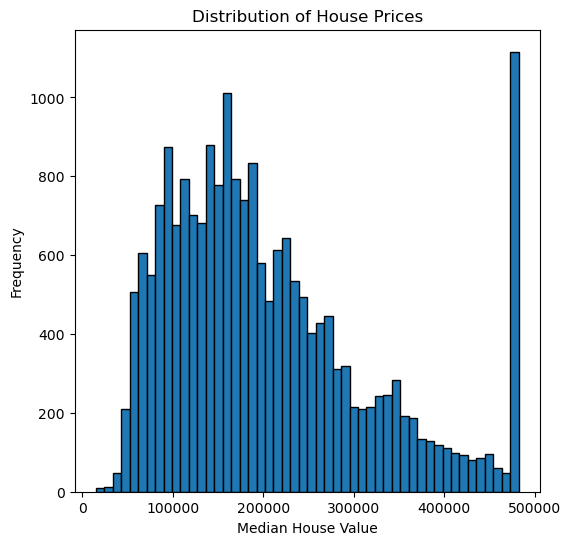

In [42]:
plt.figure(figsize = (6,6))
plt.hist(df['median_house_value'],bins=50,edgecolor='black');
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')

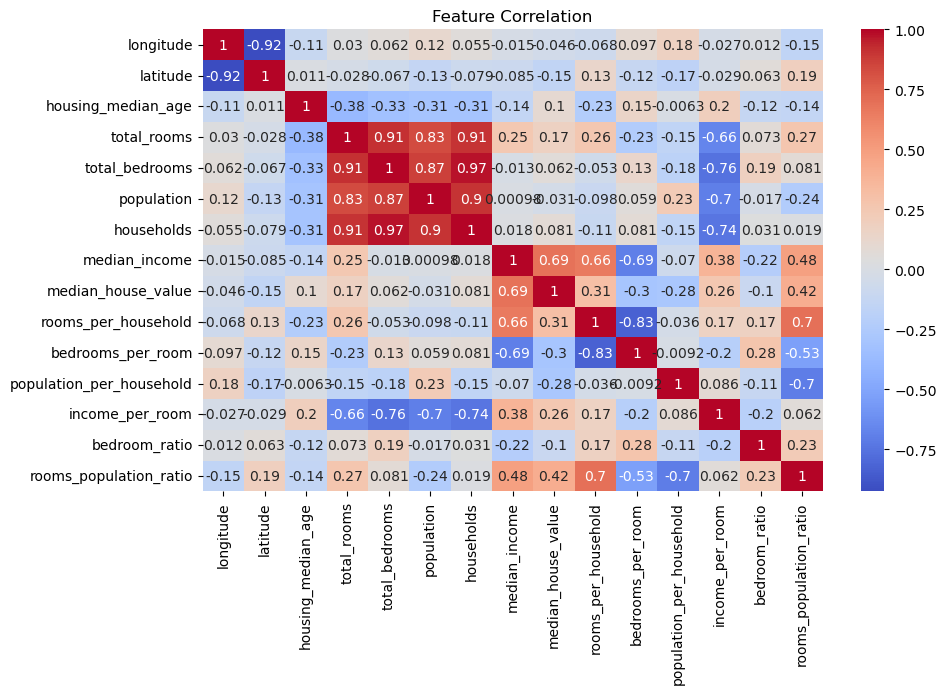

In [43]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Feature Correlation")
plt.show()


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>,
        <Axes: title={'center': 'total_rooms'}>],
       [<Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>,
        <Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>],
       [<Axes: title={'center': 'median_house_value'}>,
        <Axes: title={'center': 'rooms_per_household'}>,
        <Axes: title={'center': 'bedrooms_per_room'}>,
        <Axes: title={'center': 'population_per_household'}>],
       [<Axes: title={'center': 'income_per_room'}>,
        <Axes: title={'center': 'bedroom_ratio'}>,
        <Axes: title={'center': 'rooms_population_ratio'}>, <Axes: >]],
      dtype=object)

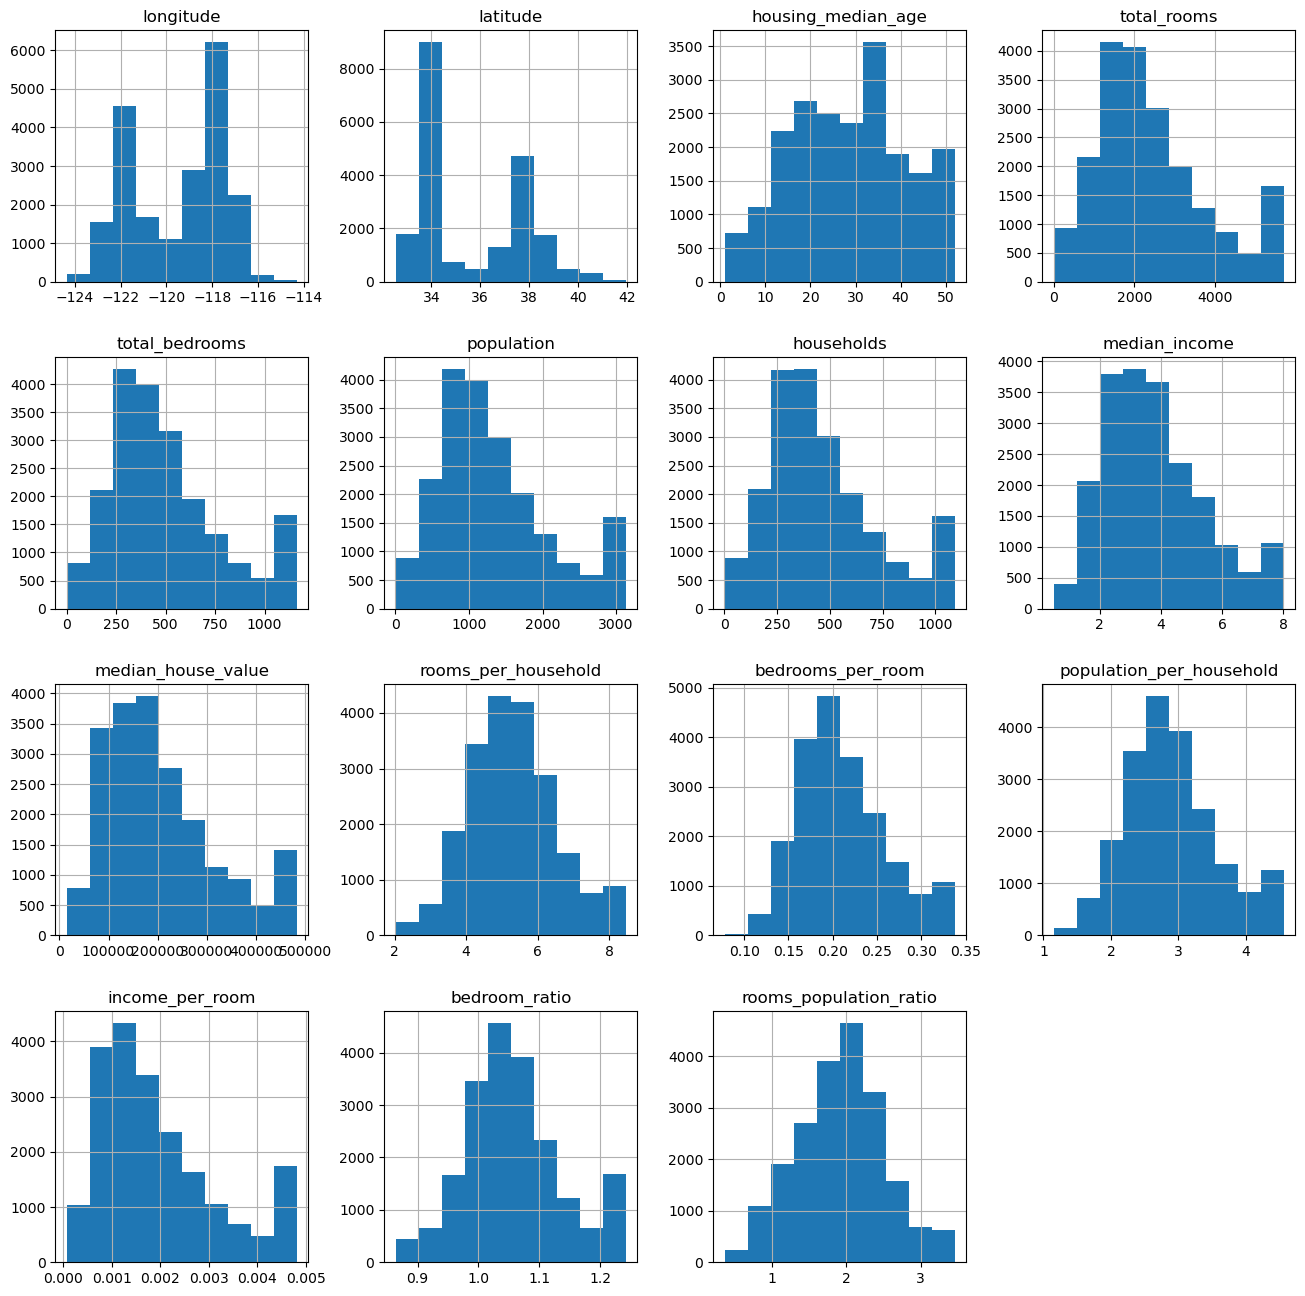

In [44]:
df.hist(figsize=(16,16))

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
model = XGBRegressor(n_estimators=1000,learning_rate=0.02,max_depth=7,subsample=0.9,colsample_bytree=0.9,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [46]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.8506057109776425


Text(0.5, 0, 'Importance')

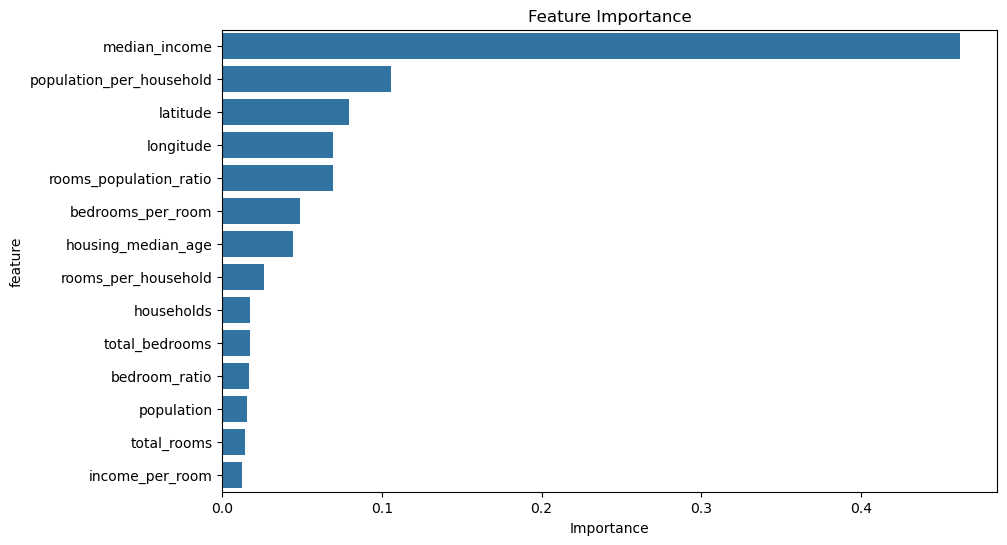

In [47]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance')
plt.xlabel('Importance')

In [48]:
hist_fig = px.histogram(df, x="median_house_value", nbins=50,title="House Price Distribution")

heatmap_fig = px.imshow(df.corr(numeric_only=True),title="Correlation Heatmap")

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_fig = px.bar(importance_df,x="Importance", y="Feature",orientation="h", title="Feature Importance")

In [ ]:
app = dash.Dash(__name__)

app.layout = html.Div([

    html.H1("Advanced House Price Dashboard",
            style={"textAlign": "center"}),

    html.Div([
        html.Div([
            html.H3("Model Accuracy"),
            html.H2(f"{r2:.3f}")
        ]),

        html.Div([
            html.H3("Dataset Size"),
            html.H2(f"{len(df)} rows")
        ]),
    ], style={"display": "flex", "justifyContent": "space-around"}),

    html.Br(),

    html.Div([
        dcc.Graph(figure=hist_fig),
        dcc.Graph(figure=heatmap_fig)
    ], style={"display": "grid", "gridTemplateColumns": "1fr 1fr"}),

    html.Br(),

    dcc.Graph(figure=importance_fig),

    html.H2(" Live Prediction", style={"textAlign": "center"}),

    html.Div([

        html.Label("Median Income"),
        dcc.Slider(0, 15, 0.1, value=3, id="income"),

        html.Label("House Age"),
        dcc.Slider(1, 50, 1, value=20, id="age"),

        html.Label("Total Rooms"),
        dcc.Slider(100, 10000, 100, value=2000, id="rooms"),

        html.Label("Population"),
        dcc.Slider(50, 5000, 50, value=1000, id="population"),

    ], style={"width": "60%", "margin": "auto"}),

    html.Br(),

    html.H2(id="output", style={
        "textAlign": "center",
        "color": "green"
    })

])

@app.callback(
    Output("output", "children"),
    Input("income", "value"),
    Input("age", "value"),
    Input("rooms", "value"),
    Input("population", "value")
)
def predict(income, age, rooms, population):

    households = rooms / 3
    bedrooms = rooms * 0.2

    input_data = pd.DataFrame([{
        "median_income": income,
        "housing_median_age": age,
        "total_rooms": rooms,
        "total_bedrooms": bedrooms,
        "population": population,
        "households": households,
    }])

    
    input_data["rooms_per_household"] = input_data["total_rooms"] / input_data["households"]
    input_data["bedrooms_per_room"] = input_data["total_bedrooms"] / input_data["total_rooms"]
    input_data["population_per_household"] = input_data["population"] / input_data["households"]


    for col in X.columns:
        if col not in input_data.columns:
            input_data[col] = 0

    input_data = input_data[X.columns]

    pred = model.predict(input_data)[0]

    return f" Estimated Price:{pred:,.0f}"

if __name__ == "__main__":
    app.run(debug=True)